# 地理空间分析
### 订单分布分析
通过地理空间分析，可以识别出订单量最高的地区，帮助优化物流和仓储布局, 圣保罗和里约热内卢是订单量较高的地区，可以考虑在这些地区增加仓储设施。

### 运输成本分析
通过分析运输成本与订单金额的比例，可以识别出哪些地区的运输成本较高，进而优化物流路线或调整定价策略, 北部和东北部地区的运输成本较高，可能需要考虑与当地物流公司合作以降低成本。

### 客户满意度分析
通过分析客户评分与交付时间的关系，可以识别出哪些地区的客户满意度较低，进而改进服务质量, 北部和东北部地区的交付时间较长，可能需要优化这些地区的物流网络。

#### 订单延迟分析
通过分析订单延迟的比例，可以识别出哪些地区的物流效率较低，进而采取措施提高交付速度, 里约热内卢的郊区订单延迟较多，可能需要增加这些地区的物流资源。

#### 数据集
Olist 发布了一个包含 2016 年至 2018 年间 100,000 笔订单的数据集。每个订单都包含一些关于客户的信息，并且包含客户的邮政编码的前三位数字。Olist 还发布了一个地理定位数据库，其中包含 323,000 个与每个邮政编码的前三位数字相关的经纬度坐标。

#### CEP: 巴西邮政编码
巴西的邮政编码，也称为 CEP，代表邮政地址代码（*Código de Endereçamento Postal*），包含 8 位数字。CEP 最初在 1972 年以五位数字的序列引入，后于 1992 年扩展到八位数字，以实现更精确的定位。标准格式为“nnnnn-nnn”（原始的五位数字，一个连字符，以及新增的三位数字）。

**示例：**
- **CEP:** 12.345-678
- 前一部分由 5 位数字组成，分别代表区域、次区域、区域、次区域和次区域细分。
- 后一部分包含 3 位数字，由连字符与前一部分分隔，代表分发标识符。

有关 CEP 如何工作的更多信息可在 [Correios 网站](https://www.correios.com.br/a-a-z/cep-codigo-de-enderecamento-postal) 查阅。
让我们来查看 Olist 提供的地理定位数据集，并尝试理解 CEP 在地理上的工作原理。
有19.051个不同的zip_code_prefix。平均每个前缀有52.6个坐标。但有一个前缀只有1.146个坐标可用。


核心发现

| 指标               | 东南部（如圣保罗） | 北部（如亚马逊州） | 业务启示                      |
|--------------------|----------------------|----------------------|-----------------------------|
| CLV中位数          | R$ 850             | R$ 220             | 资源向高价值区域倾斜          |
| 物流按时交付率     | 92%                  | 68%                  | 北部需优化物流合作伙伴        |
| 客户评分           | 4.3/5.0            | 3.7/5.0            | 提升北部售后服务响应速度      |
| 订单延迟率         | 8%                   | 32%                  | 增加北部仓储节点以缩短配送距离|



In [1]:
import os
import numpy as np
import pandas as pd 
from datashader.utils import lnglat_to_meters as webm

geo = pd.read_csv("data/olist_public_dataset/olist_geolocation_dataset.csv", dtype={'geolocation_zip_code_prefix': str})

# 获取邮政编码的前三位和前四位数字
geo['geolocation_zip_code_prefix_1_digits'] = geo['geolocation_zip_code_prefix'].str[0:1]
geo['geolocation_zip_code_prefix_2_digits'] = geo['geolocation_zip_code_prefix'].str[0:2]
geo['geolocation_zip_code_prefix_3_digits'] = geo['geolocation_zip_code_prefix'].str[0:3]
geo['geolocation_zip_code_prefix_4_digits'] = geo['geolocation_zip_code_prefix'].str[0:4]
geo.head(3)


f:\（4）Pysual Code\.venv\lib\site-packages\dask\dataframe\__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state,geolocation_zip_code_prefix_1_digits,geolocation_zip_code_prefix_2_digits,geolocation_zip_code_prefix_3_digits,geolocation_zip_code_prefix_4_digits
0,01037,-23.545621,-46.639292,sao paulo,SP,0,01,010,0103
1,01046,-23.546081,-46.644820,sao paulo,SP,0,01,010,0104
2,01046,-23.546129,-46.642951,sao paulo,SP,0,01,010,0104


In [2]:
# 移除一些异常值
geo = geo[geo.geolocation_lat <= 5.27438888]  ## 北端罗赖马州
geo = geo[geo.geolocation_lng >= -73.98283055]  ##南端南里奥格兰德州
geo = geo[geo.geolocation_lat >= -33.75116994]  ## 东端费尔南多·迪诺罗尼亚群岛
geo = geo[geo.geolocation_lng <=  -34.79314722]  ## 西端阿克里州
geo = geo.dropna(subset=['geolocation_lat', 'geolocation_lng']) # 处理缺失值
geo = geo.drop_duplicates(subset=['geolocation_zip_code_prefix'])  # 去除重复数据

# 然后我们处理纬度和经度坐标，并将它们转换为墨卡托x/y坐标。
x, y = webm(geo.geolocation_lng, geo.geolocation_lat)
geo['x'] = pd.Series(x)
geo['y'] = pd.Series(y)
# geo["x"], geo["y"] = lnglat_to_meters(geo["geolocation_lng"], geo["geolocation_lat"])

在地图上绘制坐标。发现邮政编码前缀与该邮政编码的位置之间存在关系。它们从圣保罗开始，前缀为01001，然后逆时针方向增加，最后在巴西南部的里约格兰德州结束，前缀为99990。

In [3]:
# transforming the prefixes to int for plotting purposes
geo['geolocation_zip_code_prefix'] = geo['geolocation_zip_code_prefix'].astype(int)
geo['geolocation_zip_code_prefix_1_digits'] = geo['geolocation_zip_code_prefix_1_digits'].astype(int)
geo['geolocation_zip_code_prefix_2_digits'] = geo['geolocation_zip_code_prefix_2_digits'].astype(int)
geo['geolocation_zip_code_prefix_3_digits'] = geo['geolocation_zip_code_prefix_3_digits'].astype(int)
geo['geolocation_zip_code_prefix_4_digits'] = geo['geolocation_zip_code_prefix_4_digits'].astype(int)
brazil = geo
agg_name = 'geolocation_zip_code_prefix'
brazil[agg_name].describe().to_frame()

,geolocation_zip_code_prefix
count,19010.000000
mean,42705.532562
std,30903.692720
min,1001.000000
25%,12720.250000
50%,38225.000000
75%,70649.500000
max,99990.000000


Loading BokehJS ...

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
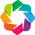

In [4]:
# 使用全息视图 + 数据着色器进行绘图 - 带有地图背景的散景
import holoviews as hv
import geoviews as gv
import datashader as ds
from colorcet import fire, rainbow, bgy, bjy, bkr, kb, kr
from datashader.colors import colormap_select, Greys9
from holoviews.streams import RangeXY
from holoviews.operation.datashader import datashade, dynspread, rasterize
from bokeh.io import push_notebook, show, output_notebook
output_notebook()
hv.extension('bokeh')

# 设置绘图的默认选项，包括宽度、高度、工具栏位置、坐标轴显示等
%opts Overlay [width=800 height=600 toolbar='above' xaxis=None yaxis=None]
# 设置QuadMesh的默认选项，包括工具、颜色条、透明度等
%opts QuadMesh [tools=['hover'] colorbar=True] (alpha=0 hover_alpha=0.2)

# 定义点聚集的阈值和最大像素值
T = 0.05
PX = 1

# 定义一个函数，用于绘制带有地理背景的地图
def plot_map(data, label, agg_data, agg_name, cmap):
    # 地图服务的URL
    url="http://server.arcgisonline.com/ArcGIS/rest/services/Canvas/World_Dark_Gray_Base/MapServer/tile/{Z}/{Y}/{X}.png"
    # 创建一个WMTS地图对象
    geomap = gv.WMTS(url)
    # 创建一个包含数据点的Points对象
    points = hv.Points(gv.Dataset(data, kdims=['x', 'y'], vdims=[agg_name]))
    # 使用datashader对点数据进行聚集并转换为图像
    agg = datashade(points, element_type=gv.Image, aggregator=agg_data, cmap=cmap)
    # 使用dynspread动态扩展聚集后的图像
    zip_codes = dynspread(agg, threshold=T, max_px=PX)
    # 创建一个动态的Hover效果，显示详细信息
    hover = hv.util.Dynamic(rasterize(points, aggregator=agg_data, width=50, height=25, streams=[RangeXY]), operation=hv.QuadMesh)
    # 设置Hover效果的颜色映射
    hover = hover.options(cmap=cmap)
    # 将地图、聚集后的图像和Hover效果叠加在一起
    img = geomap * zip_codes * hover
    # 重命名图像的标签
    img = img.relabel(label)
    # 返回最终的图像对象
    return img

In [5]:
# 使用数据着色器绘制 - 黑色背景的图像
import datashader as ds
from datashader import transfer_functions as tf
from functools import partial
from datashader.utils import export_image
from IPython.core.display import HTML, display
from colorcet import fire, rainbow, bgy, bjy, bkr, kb, kr

background = "black"
cm = partial(colormap_select, reverse=(background!="black"))
export = partial(export_image, background = background, export_path="export")
display(HTML("<style>.container { width:100% !important; }</style>"))
W = 700 

def create_map(data, cmap, data_agg, export_name='img'):
    pad = (data.x.max() - data.x.min())/50
    x_range, y_range = ((data.x.min() - pad, data.x.max() + pad), 
                             (data.y.min() - pad, data.y.max() + pad))

    ratio = (y_range[1] - y_range[0]) / (x_range[1] - x_range[0])

    plot_width  = int(W)
    plot_height = int(plot_width * ratio)
    if ratio > 1.5:
        plot_height = 550
        plot_width = int(plot_height / ratio)
        
    cvs = ds.Canvas(plot_width=plot_width, plot_height=plot_height, x_range=x_range, y_range=y_range)

    agg = cvs.points(data, 'x', 'y', data_agg)
    img = tf.shade(agg, cmap=cmap, how='eq_hist')
    return export(img, export_name)

C:\Users\yohoten\AppData\Local\Temp\ipykernel_4460\14821436.py:6: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import HTML, display


In [6]:
plot_map(brazil, '巴西的邮政编码', ds.min(agg_name), agg_name, cmap=rainbow)

BokehModel(combine_events=True, render_bundle={'docs_json': {'c4a88c39-fae6-4c42-bc04-6899fd3d2bea': {'version…

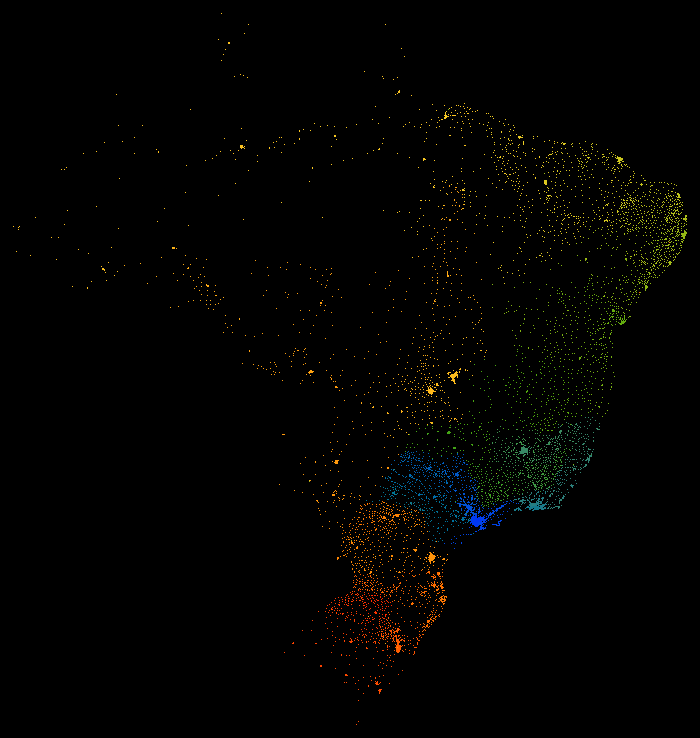

In [7]:
create_map(brazil, rainbow, ds.mean(agg_name),'巴西的邮政编码')

#### 圣保罗州（SP）的邮政编码前缀是如何在区域层面上工作的。我们发现：
* 圣保罗州的邮政编码前缀范围从01001到19990
* 以0开头的邮政编码位于圣保罗大都市区
* 以1开头的邮政编码位于州的内陆地区

In [8]:
def filter_data(level, name):
    df = geo[geo[level] == name]
    #remove outliers
    df = df[(df.x <= df.x.quantile(0.999)) & (df.x >= df.x.quantile(0.001))]
    df = df[(df.y <= df.y.quantile(0.999)) & (df.y >= df.y.quantile(0.001))]
    return df
sp = filter_data('geolocation_state', 'SP')
agg_name = 'geolocation_zip_code_prefix'
sp[agg_name].describe().to_frame()

,geolocation_zip_code_prefix
count,6320.000000
mean,8073.734968
std,5189.802264
min,1001.000000
25%,3904.750000
50%,6327.500000
75%,12702.250000
max,19990.000000


In [9]:
plot_map(sp, '圣保罗州的邮政编码', ds.min(agg_name), agg_name, cmap=rainbow)

BokehModel(combine_events=True, render_bundle={'docs_json': {'aa2f9d98-7740-46a9-be6b-8c0ad30fb447': {'version…

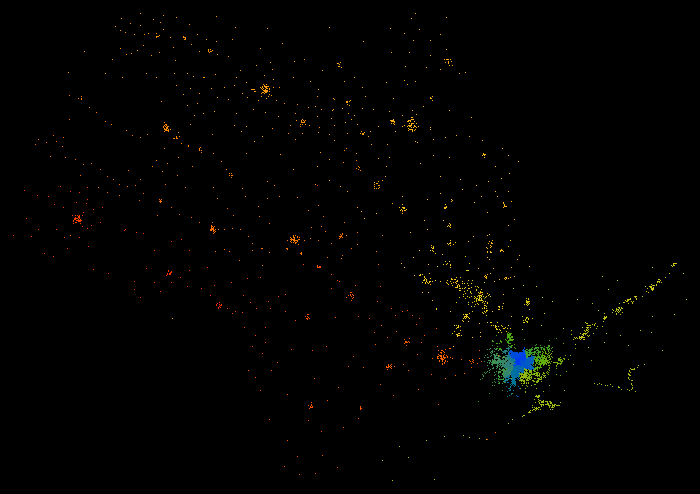

In [10]:
create_map(sp, rainbow, ds.mean(agg_name), '圣保罗州的邮政编码')


##### 大城市中的邮政编码
让我们看看圣保罗市，看看邮政编码前缀如何在城市层面上工作。我们发现：
* 圣保罗市的邮政编码前缀范围从01001到09540
* 邮政编码前缀与某些街区或城市区域有关


In [11]:
saopaulo = filter_data('geolocation_city', 'sao paulo')
agg_name = 'geolocation_zip_code_prefix'
saopaulo[agg_name].describe().to_frame()

,geolocation_zip_code_prefix
count,2640.000000
mean,3881.801515
std,1562.405880
min,1001.000000
25%,2816.500000
50%,3892.500000
75%,4896.250000
max,8490.000000


In [12]:
plot_map(saopaulo, '圣保罗市的邮政编码', ds.min(agg_name), agg_name, cmap=rainbow)

BokehModel(combine_events=True, render_bundle={'docs_json': {'cbf74873-15b4-42db-a2ba-db764fc91e92': {'version…

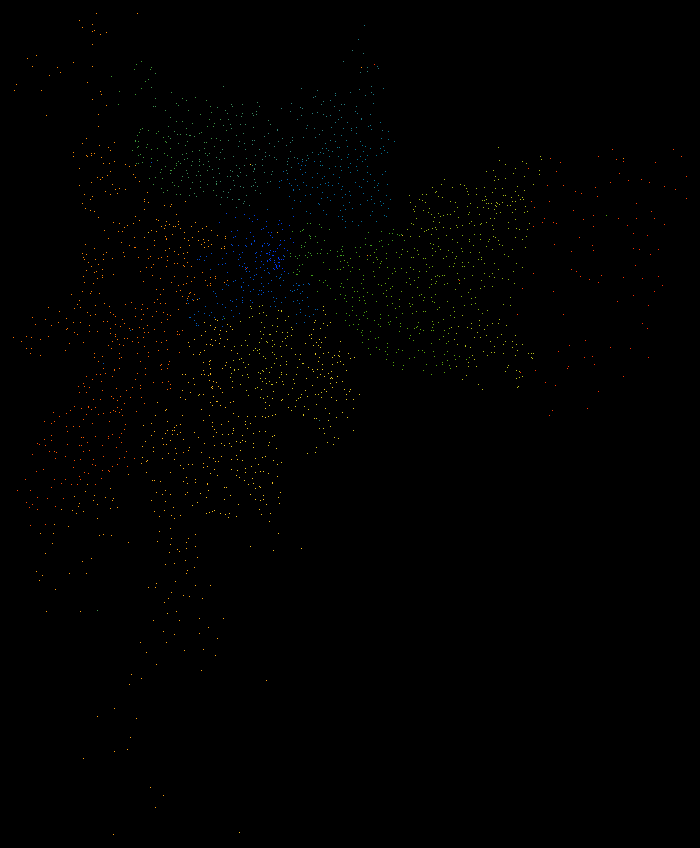

In [13]:
create_map(saopaulo, rainbow, ds.mean(agg_name), '圣保罗市的邮政编码')


#### 小城市的邮政编码
让我们以阿提巴亚市为例，看看邮政编码前缀在城市层面是如何工作的。我们发现：
* 阿提巴亚市的邮政编码前缀介于12940和12954之间
* 但其他邻近城市可能使用相同的邮政编码前缀
* 为了获得更详细的信息并缩小到城市层面，我们可能需要更多的邮政编码数字（即第四位和第五位）


In [14]:
atibaia = geo[geo['geolocation_city'] == 'atibaia']
agg_name = 'geolocation_zip_code_prefix'
atibaia[agg_name].describe().to_frame()

,geolocation_zip_code_prefix
count,15.000000
mean,12947.000000
std,4.472136
min,12940.000000
25%,12943.500000
50%,12947.000000
75%,12950.500000
max,12954.000000


In [15]:
plot_map(atibaia, '阿蒂巴亚的邮政编码', ds.min(agg_name), agg_name, cmap=rainbow)

BokehModel(combine_events=True, render_bundle={'docs_json': {'3b6f5d7b-f200-42c7-9150-1db8d9bf3ec2': {'version…

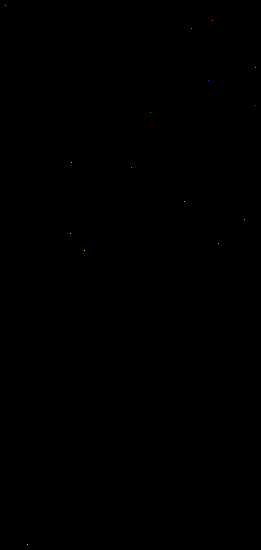

In [16]:
create_map(atibaia, rainbow, ds.mean(agg_name), '阿蒂巴亚的邮政编码')

**以 2 开头的邮政编码都来自里约热内卢州 (RJ) 和圣埃斯皮里图州 (ES)**

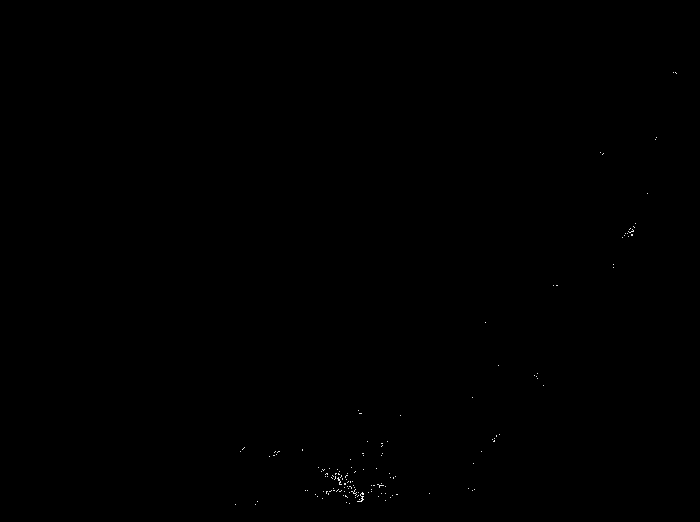

In [17]:
# Zip code: 2
df = filter_data('geolocation_zip_code_prefix_1_digits', 2)
create_map(df, cm(Greys9), ds.count(), 'zip_code_2')

**以22开头的邮编都在里约热内卢市内，但它们代表多个不同的街区**

从右到左，你可以看到诸如莱梅、科帕卡巴纳、伊帕内马、莱布隆和蒂茹卡巴拉这样的街区。


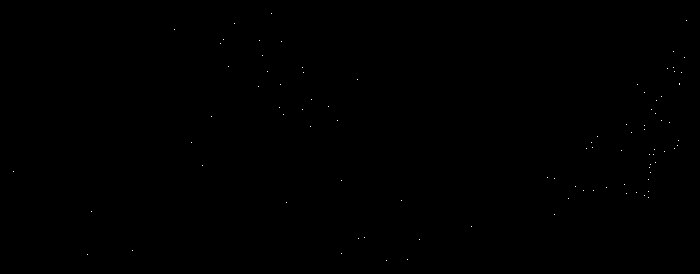

In [18]:
# Zip code: 22
df = filter_data('geolocation_zip_code_prefix_2_digits', 22)
create_map(df, cm(Greys9), ds.count(), 'zip_code_22')

**邮政编码以 220 开头的地区均位于里约热内卢的科帕卡巴纳区**

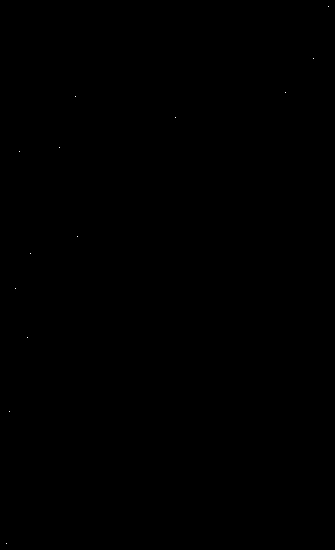

In [19]:
# Zip code: 220
df = filter_data('geolocation_zip_code_prefix_3_digits', 220)
create_map(df, cm(Greys9), ds.count(), 'zip_code_220')

**以2201开头的邮政编码代表里约热内卢科帕卡巴纳区的一些街道**


In [20]:
# # Zip code: 2201
# df = filter_data('geolocation_zip_code_prefix_4_digits', 2201)
# create_map(df, cm(Greys9), ds.count(), 'zip_code_2201')

**以 22010 开头的邮政编码代表科帕卡巴纳的街道设置更为严格**

In [21]:
# # Zip code: 22010
# df = filter_data('geolocation_zip_code_prefix', 22010)
# create_map(df, cm(Greys9), ds.count(), 'zip_code_22010')

#### 大部分收入来自哪里？

使用 5 位邮政编码可能会导致我们在某些地区得到非常小的样本，因此我们将使用 3 位数字。绘制按邮政编码前缀分组的产品价值总和，我们发现大部分收入来自巴西的东南部和南部地区。还可以看到，人口较多的大城市和首都的收入参与度更高。

In [22]:
orders_df = pd.read_csv('data/olist_public_dataset/olist_orders_dataset.csv')
order_items = pd.read_csv('data/olist_public_dataset/olist_order_items_dataset.csv')
order_reviews = pd.read_csv('data/olist_public_dataset/olist_order_reviews_dataset.csv')
customer = pd.read_csv('data/olist_public_dataset/olist_customers_dataset.csv', dtype={'customer_zip_code_prefix': str})

# 获取客户邮政编码的前三位数字
customer['customer_zip_code_prefix_3_digits'] = customer['customer_zip_code_prefix'].str[0:3]
customer['customer_zip_code_prefix_3_digits'] = customer['customer_zip_code_prefix_3_digits'].astype(int)

brazil_geo = geo.set_index('geolocation_zip_code_prefix_3_digits').copy()

# 合并数据
orders = orders_df.merge(order_items, on='order_id')
orders = orders.merge(customer, on='customer_id')
orders = orders.merge(order_reviews, on='order_id')

gp = orders.groupby('customer_zip_code_prefix_3_digits')['price'].sum().to_frame()
revenue = brazil_geo.join(gp)
agg_name = 'revenue'
revenue[agg_name] = revenue.price / 1000

In [23]:
plot_map(revenue, '订单收入（千巴西雷亚尔）(thousands R$)', ds.mean(agg_name), agg_name, cmap=fire)

BokehModel(combine_events=True, render_bundle={'docs_json': {'0d14789d-7ee6-4f7b-aaef-fd3f6643c223': {'version…

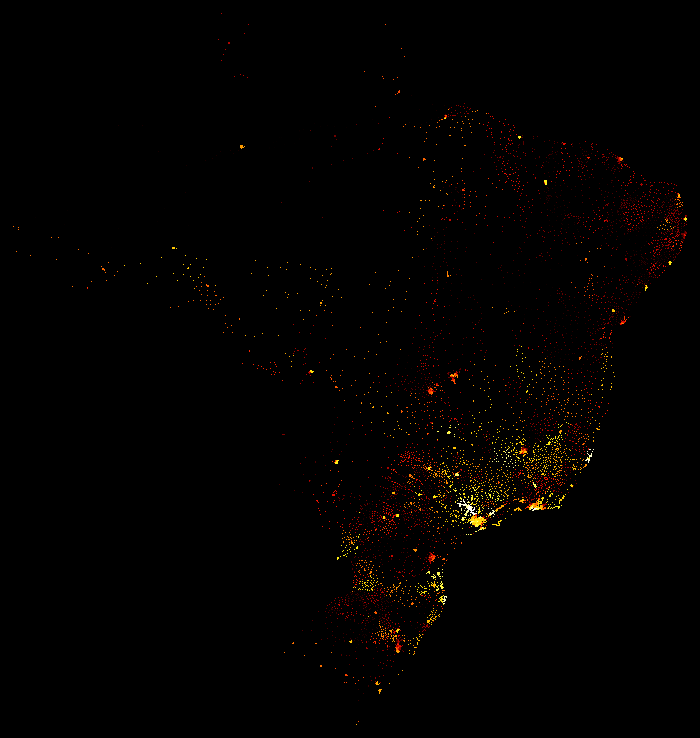

In [24]:
create_map(revenue, fire, ds.mean(agg_name), '收入_巴西')

#### 平均购买价格 ？
巴西南部和东南部地区的客户的平均票价低于北部和东北部的同行，支付更多的运费

In [25]:
gp = orders.groupby('order_id').agg({'price': 'sum', 'customer_zip_code_prefix_3_digits': 'max'})
gp = gp.groupby('customer_zip_code_prefix_3_digits')['price'].mean().to_frame()
avg_ticket = brazil_geo.join(gp)
agg_name = 'avg_ticket'
avg_ticket[agg_name] = avg_ticket.price

plot_map(avg_ticket, '订单平均票价（R$）', ds.mean(agg_name), agg_name, cmap=bgy)

BokehModel(combine_events=True, render_bundle={'docs_json': {'097dba88-c017-4e05-b9ea-db3a98124b26': {'version…

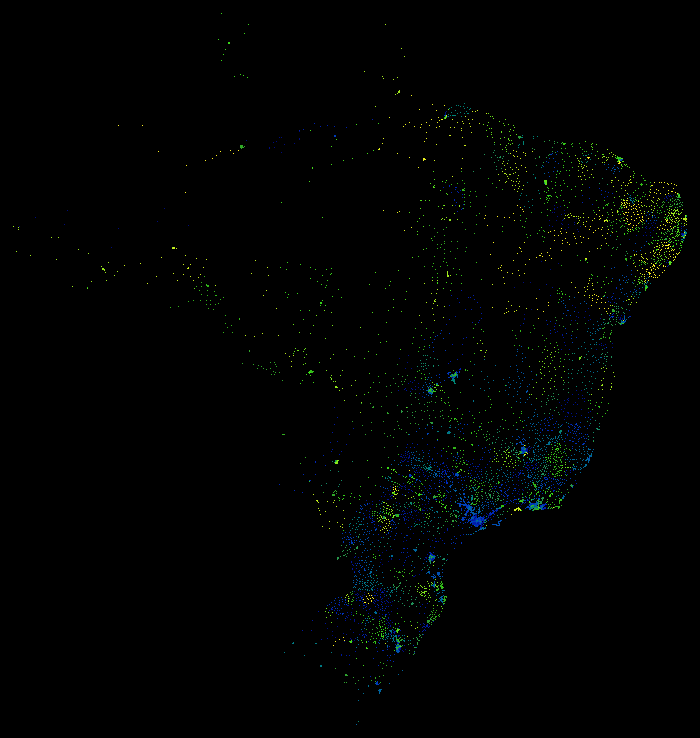

In [26]:
create_map(avg_ticket, bgy, ds.mean('avg_ticket'), '平均票价巴西')

#### 支付的运输费用对比
**运费比率 = 运费价值 / 订单价**

该比率表示一个人为了收到订单而必须支付的产品价格百分比。例如，如果产品价格为 R\$50.00，运费价值为 R\$10.00，则运费比率为 0.2 或 20%。较高的运费比率很可能会阻止客户完成购买。由于物流成本，我们预计人口密集地区的运费比率较低，而人口稀少地区的运费比率较高。

In [27]:
gp = orders.groupby('order_id').agg({'price': 'sum', 'freight_value': 'sum', 'customer_zip_code_prefix_3_digits': 'max'})
agg_name = 'freight_ratio'
gp[agg_name] = gp.freight_value / gp.price
gp = gp.groupby('customer_zip_code_prefix_3_digits')[agg_name].mean().to_frame()
freight_ratio = brazil_geo.join(gp)

plot_map(freight_ratio, '订单平均运费比率', ds.mean(agg_name), agg_name, cmap=bgy)

BokehModel(combine_events=True, render_bundle={'docs_json': {'e410abac-f8f6-4dd1-b007-bea66b613405': {'version…

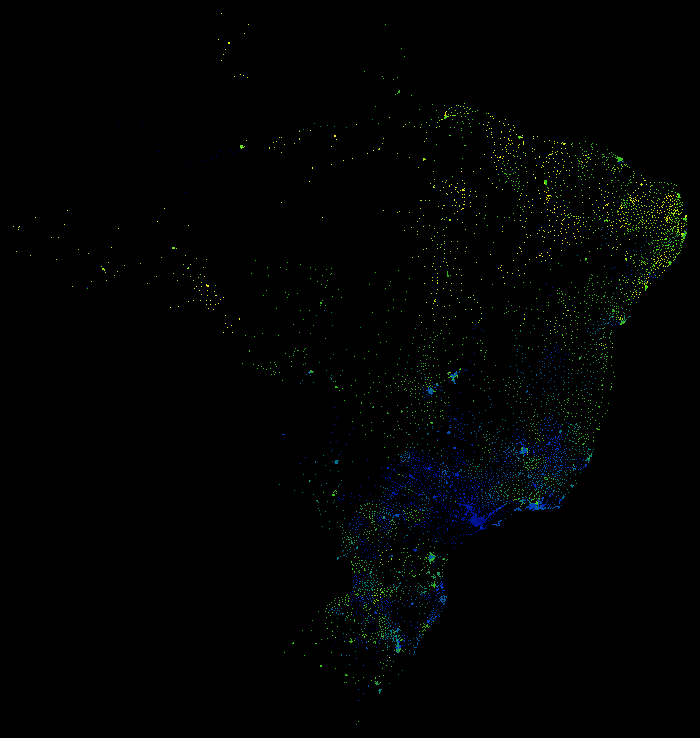

In [28]:
create_map(freight_ratio, bgy, ds.mean('freight_ratio'), '运费比率_巴西')

#### 平均交货时间 
居住在巴西北部和东北部的人必须承受更高的运费，并且必须等待更长的时间才能收到他们购买的商品。

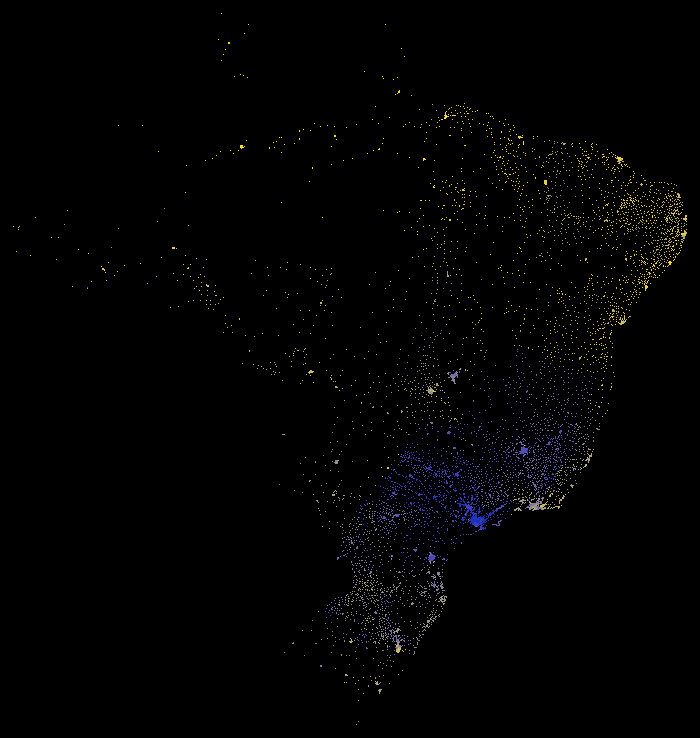

In [29]:
orders['order_delivered_customer_date'] = pd.to_datetime(orders.order_delivered_customer_date)
orders['order_estimated_delivery_date'] = pd.to_datetime(orders.order_estimated_delivery_date)
orders['order_delivered_carrier_date'] = pd.to_datetime(orders.order_delivered_carrier_date)
orders['actual_delivery_time'] = orders.order_delivered_customer_date - orders.order_delivered_carrier_date
orders['actual_delivery_time'] = orders['actual_delivery_time'].dt.days

gp = orders.groupby('customer_zip_code_prefix_3_digits')['actual_delivery_time'].mean().to_frame()
delivery_time = brazil_geo.join(gp)
agg_name = 'avg_delivery_time'
delivery_time[agg_name] = delivery_time['actual_delivery_time']

plot_map(delivery_time, '订单平均配送时间（天）', ds.mean(agg_name), agg_name, cmap=bjy)

create_map(delivery_time, bjy, ds.mean(agg_name), '平均送货时间——巴西')

In [30]:
pr = filter_data('geolocation_state', 'PR').set_index('geolocation_zip_code_prefix_3_digits')
gp = orders.groupby('customer_zip_code_prefix_3_digits')['actual_delivery_time'].mean().to_frame()
pr_delivery_time = pr.join(gp)
pr_delivery_time[agg_name] = pr_delivery_time['actual_delivery_time']

plot_map(pr_delivery_time, '巴拉那州订单平均配送时间（天）', ds.mean(agg_name), agg_name, cmap=bjy)

BokehModel(combine_events=True, render_bundle={'docs_json': {'96accea2-25eb-4327-80e7-96624f43653b': {'version…

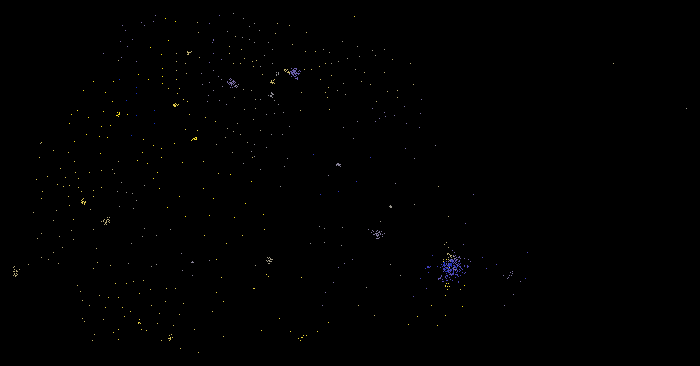

In [31]:
create_map(pr_delivery_time, bjy, ds.mean(agg_name), '平均送货时间')

关于巴西郊区的有趣之处 与其他国家不同，巴西最富裕的地区通常靠近市中心，郊区以贫穷和高暴力率而闻名。

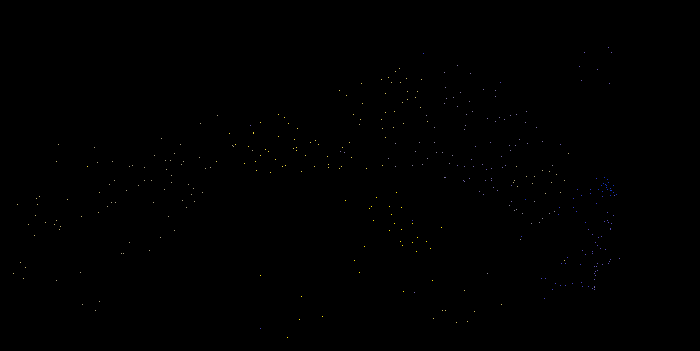

In [32]:
riodejaneiro = filter_data('geolocation_city', 'rio de janeiro').set_index('geolocation_zip_code_prefix_3_digits')
gp = orders.groupby('customer_zip_code_prefix_3_digits')['actual_delivery_time'].mean().to_frame()
rj_delivery_time = riodejaneiro.join(gp)
rj_delivery_time[agg_name] = rj_delivery_time['actual_delivery_time']

plot_map(rj_delivery_time, '里约热内卢订单平均配送时间（天）', ds.mean(agg_name), agg_name, cmap=bjy)

create_map(rj_delivery_time, bjy, ds.mean(agg_name), '里约热内卢订单平均配送时间（天）')

事实证明，如果你住在市中心、博塔弗戈、科帕卡巴纳和弗拉门戈等富裕社区，那么你收到订单的时间可能比住在 Cidade de Deus 或 Bangu 等贫困社区的人早五天。我们在圣保罗和阿雷格里港也看到了同样的情况，市中心附近的客户比住在郊区的客户收到订单的时间更快。

In [33]:
saopaulo = filter_data('geolocation_city', 'sao paulo').set_index('geolocation_zip_code_prefix_3_digits')
gp = orders.groupby('customer_zip_code_prefix_3_digits')['actual_delivery_time'].mean().to_frame()
sp_delivery_time = saopaulo.join(gp)
sp_delivery_time[agg_name] = sp_delivery_time['actual_delivery_time']

plot_map(sp_delivery_time, '圣保罗订单平均配送时间（天）', ds.mean(agg_name), agg_name, cmap=bjy)

BokehModel(combine_events=True, render_bundle={'docs_json': {'656f74d4-11f1-485b-88a7-3ba57168d21d': {'version…

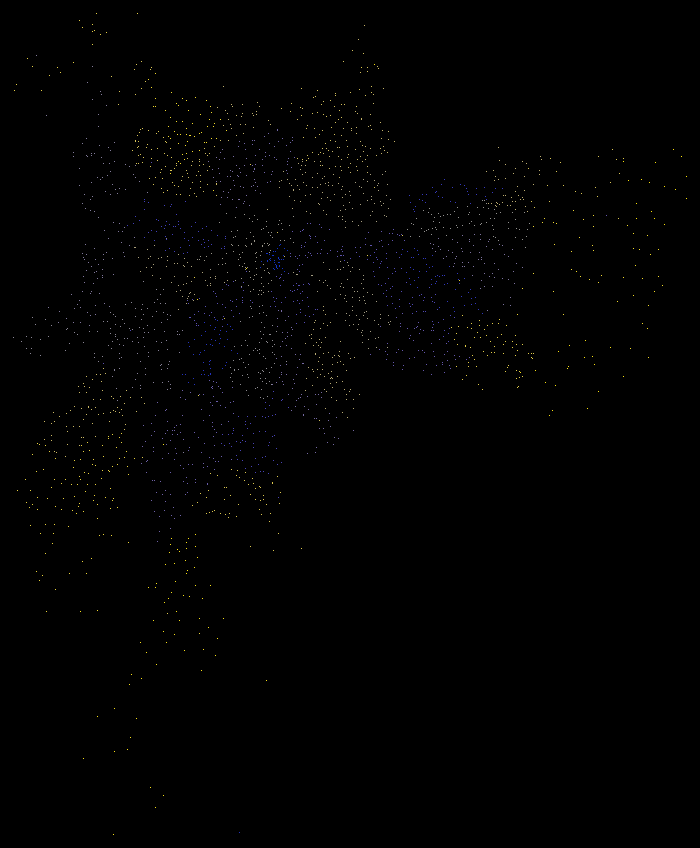

In [34]:
create_map(sp_delivery_time, bjy, ds.mean(agg_name), '圣保罗订单平均配送时间（天）')

In [35]:
poa = filter_data('geolocation_city', 'porto alegre').set_index('geolocation_zip_code_prefix_3_digits')
gp = orders.groupby('customer_zip_code_prefix_3_digits')['actual_delivery_time'].mean().to_frame()
poa_delivery_time = poa.join(gp)
poa_delivery_time[agg_name] = poa_delivery_time['actual_delivery_time']

plot_map(poa_delivery_time, '阿雷格里港订单平均配送时间（天）', ds.mean(agg_name), agg_name, cmap=bjy)

BokehModel(combine_events=True, render_bundle={'docs_json': {'0d3697ea-603c-4b13-8894-febce186397a': {'version…

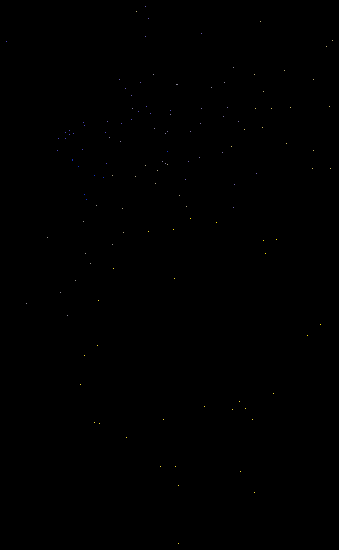

In [36]:
create_map(poa_delivery_time, bjy, ds.mean(agg_name), '阿雷格里港订单平均配送时间（天）')

订单平均评分里约热内卢州和东北地区的客户更有可能在购买时给出低分。

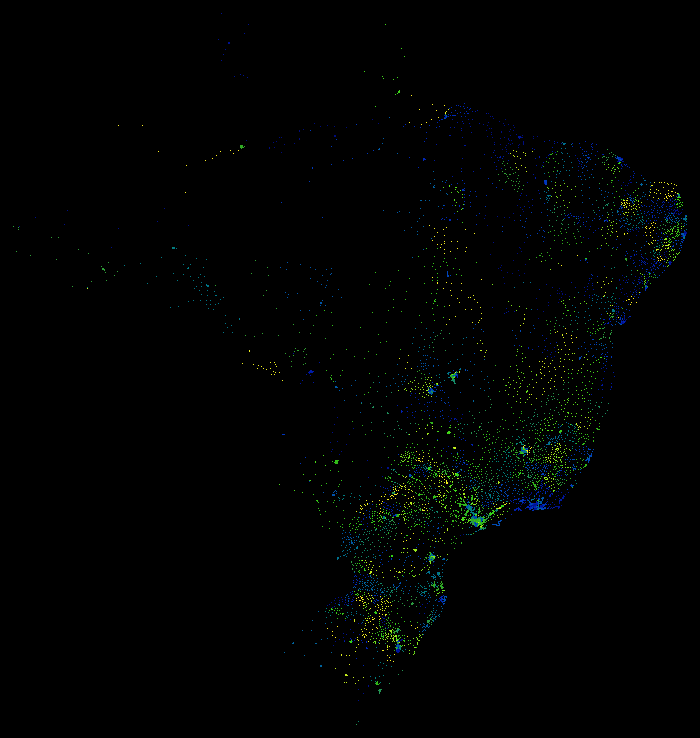

In [37]:
gp = orders.groupby('customer_zip_code_prefix_3_digits')['review_score'].mean().to_frame()
score = brazil_geo.join(gp)
agg_name = 'avg_score'
score[agg_name] = score['review_score']

plot_map(score, '订单平均评分', ds.mean(agg_name), agg_name, cmap=bgy)

create_map(score, bgy, ds.mean(agg_name), '平均评价分数(brazil)')

让我们看看里约热内卢的平均评分是多少？你觉得它与平均送货时间有什么关系吗？

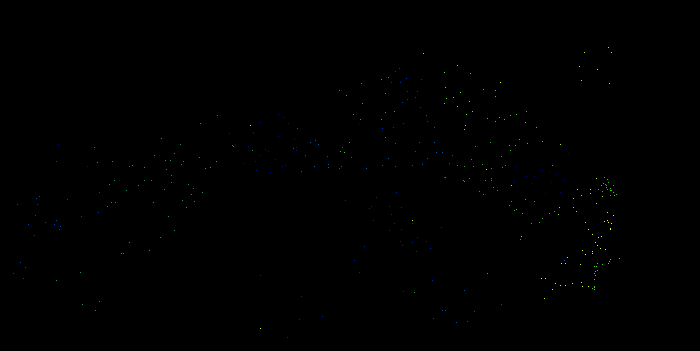

In [38]:
rj_score = riodejaneiro.join(gp)
rj_score[agg_name] = rj_score['review_score']

plot_map(rj_score, '里约热内卢订单平均评分', ds.mean(agg_name), agg_name, cmap=bgy)

create_map(rj_score, bgy, ds.mean(agg_name), '里约热内卢订单平均评分')

延迟订单让我们衡量延迟订单的百分比，看看这与客户给出的分数有何关系？

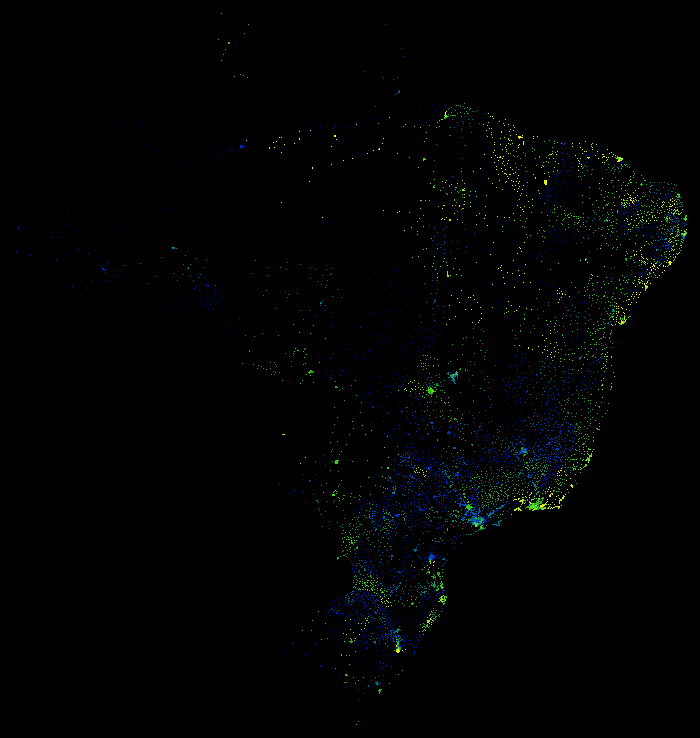

In [39]:
orders['is_delayed'] = orders['order_delivered_customer_date'] > orders['order_estimated_delivery_date'] 
gp = orders.groupby('customer_zip_code_prefix_3_digits').agg({'is_delayed': ['sum', 'count']})
agg_name = 'delayed'
gp[agg_name] = gp['is_delayed']['sum'] / gp['is_delayed']['count']
gp = gp[agg_name]
order_delay = brazil_geo.join(gp)

plot_map(order_delay, '巴西订单延迟百分比', ds.mean(agg_name), agg_name, cmap=bgy)

create_map(order_delay, bgy, ds.mean(agg_name), '巴西订单延迟分布图')

里约热内卢的订单交付更容易延迟的地方在哪？？

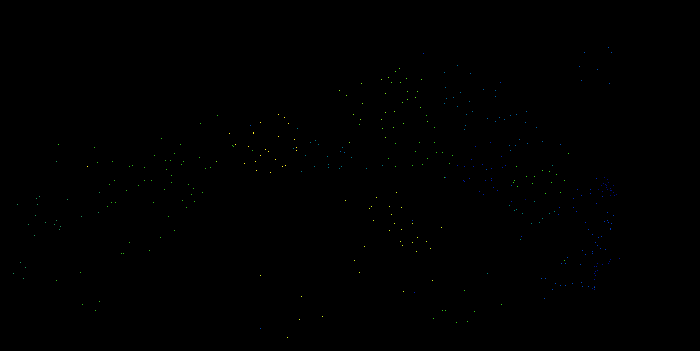

In [40]:
rj_delay = riodejaneiro.join(gp)
plot_map(rj_delay, '里约热内卢的订单延迟百分比', ds.mean(agg_name), agg_name, cmap=bgy)
create_map(rj_delay, bgy, ds.mean(agg_name), '里约热内卢的订单延迟百分比')

 小城镇的客户是否会在单笔订单中购买更多商品？让我们检查每笔订单的平均商品数量，看看远离大城市的客户是否会批量购买。

In [41]:
orders['count'] = 1
gp = orders.groupby(['customer_zip_code_prefix_3_digits','order_id'], as_index=False)['count'].count()
gp = gp.groupby('customer_zip_code_prefix_3_digits')['count'].mean().to_frame()
avg_qty = brazil_geo.join(gp)
agg_name = 'avg_qty'
avg_qty[agg_name] = avg_qty['count']

plot_map(avg_qty, '平均商品数量', ds.mean(agg_name), agg_name, cmap=bgy)

BokehModel(combine_events=True, render_bundle={'docs_json': {'53555ce4-2212-488f-afe9-2cb281ce3bb8': {'version…

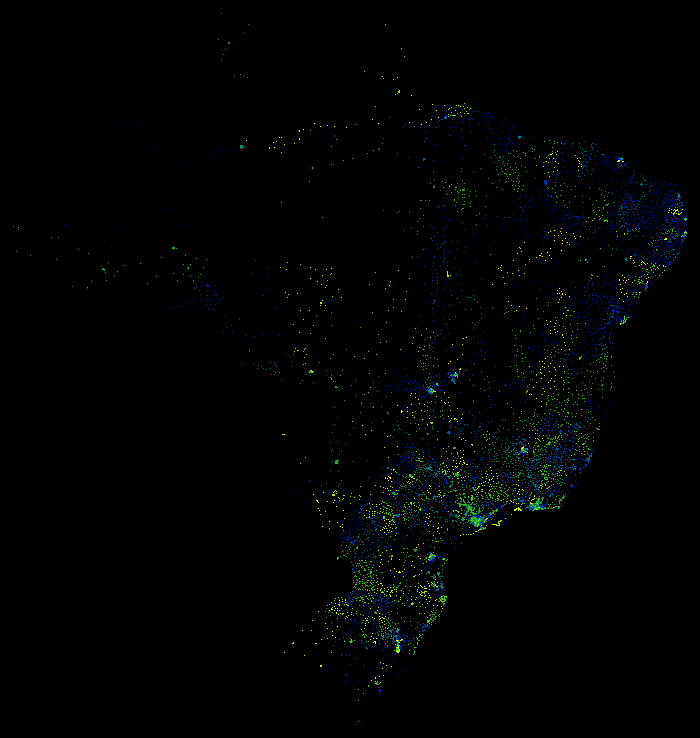

In [42]:
create_map(avg_qty, bgy, ds.mean(agg_name), '平均商品数量')

显然这个假设是错误的。看起来大城市的顾客每笔订单购买的产品更多。但是没有明确的地理模式可以让我们得出任何进一步的结论。

end